# SpiritPool — Data Analysis

Query and visualize job signal data collected by the SpiritPool extension.

**Database:** `../data/spiritpool.db` (SQLite)  
**Tables:** `companies`, `locations`, `jobs`, `observations`, `contributors`

In [7]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

DB_PATH = Path("../data/spiritpool.db")
assert DB_PATH.exists(), f"Database not found at {DB_PATH.resolve()}"

conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH.resolve()}")

Connected to /home/fortune/CodeProjects/ChainStaffingTracker/data/spiritpool.db


## 1. Database Overview

In [8]:
overview = pd.read_sql_query("""
    SELECT
        (SELECT COUNT(*) FROM jobs)         AS total_jobs,
        (SELECT COUNT(*) FROM observations) AS total_observations,
        (SELECT COUNT(*) FROM companies)    AS total_companies,
        (SELECT COUNT(*) FROM locations)    AS total_locations,
        (SELECT COUNT(*) FROM contributors) AS total_contributors
""", conn)

overview.T.rename(columns={0: "Count"}).style.format("{:,.0f}")

,Count
total_jobs,56
total_observations,180
total_companies,16
total_locations,31
total_contributors,3


## 2. Jobs by Source

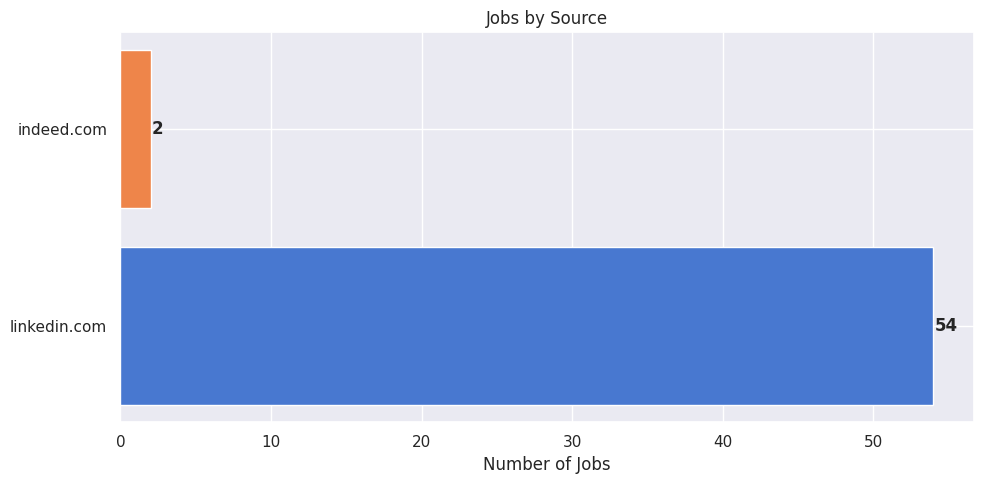

,source,job_count
0,linkedin.com,54
1,indeed.com,2


In [3]:
df_source = pd.read_sql_query("""
    SELECT source, COUNT(*) AS job_count
    FROM jobs
    GROUP BY source
    ORDER BY job_count DESC
""", conn)

fig, ax = plt.subplots()
ax.barh(df_source["source"], df_source["job_count"], color=sns.color_palette())
ax.set_xlabel("Number of Jobs")
ax.set_title("Jobs by Source")
for i, v in enumerate(df_source["job_count"]):
    ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

df_source

## 3. Top Companies by Job Count

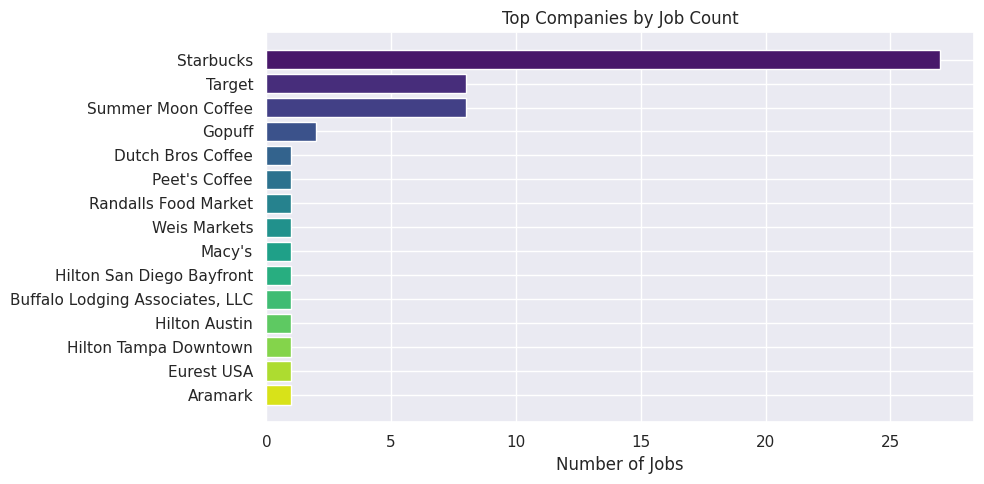

,company,job_count
0,Starbucks,27
1,Target,8
2,Summer Moon Coffee,8
3,Gopuff,2
4,Dutch Bros Coffee,1
5,Peet's Coffee,1
6,Randalls Food Market,1
7,Weis Markets,1
8,Macy's,1
9,Hilton San Diego Bayfront,1


In [4]:
df_companies = pd.read_sql_query("""
    SELECT c.name AS company, COUNT(j.id) AS job_count
    FROM companies c
    JOIN jobs j ON j.company_id = c.id
    GROUP BY c.id
    ORDER BY job_count DESC
    LIMIT 20
""", conn)

fig, ax = plt.subplots()
ax.barh(df_companies["company"], df_companies["job_count"],
        color=sns.color_palette("viridis", len(df_companies)))
ax.set_xlabel("Number of Jobs")
ax.set_title("Top Companies by Job Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

df_companies

## 4. Observations Over Time

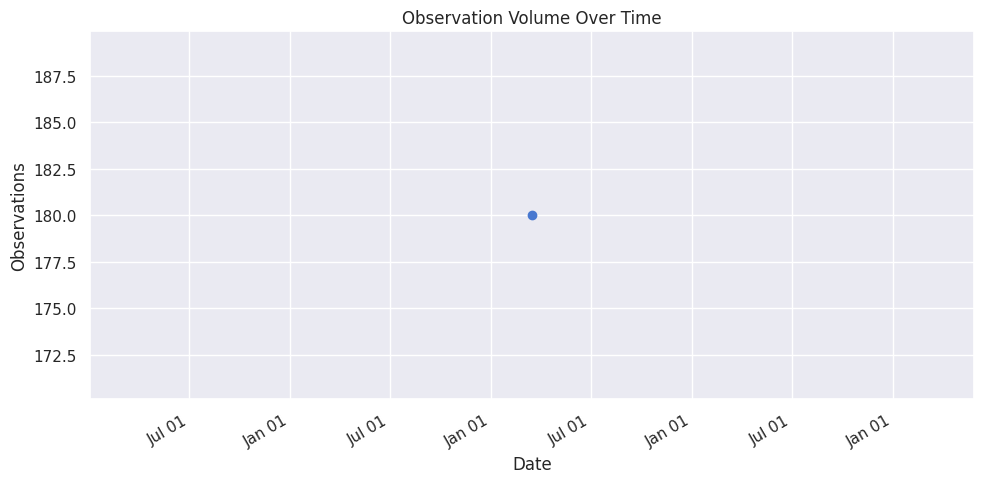

,date,observations
0,2026-03-16,180


In [5]:
df_timeline = pd.read_sql_query("""
    SELECT DATE(observed_at) AS date, COUNT(*) AS observations
    FROM observations
    GROUP BY DATE(observed_at)
    ORDER BY date
""", conn)

df_timeline["date"] = pd.to_datetime(df_timeline["date"])

fig, ax = plt.subplots()
ax.plot(df_timeline["date"], df_timeline["observations"], marker="o", linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Observations")
ax.set_title("Observation Volume Over Time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

df_timeline

## 5. Salary Distribution

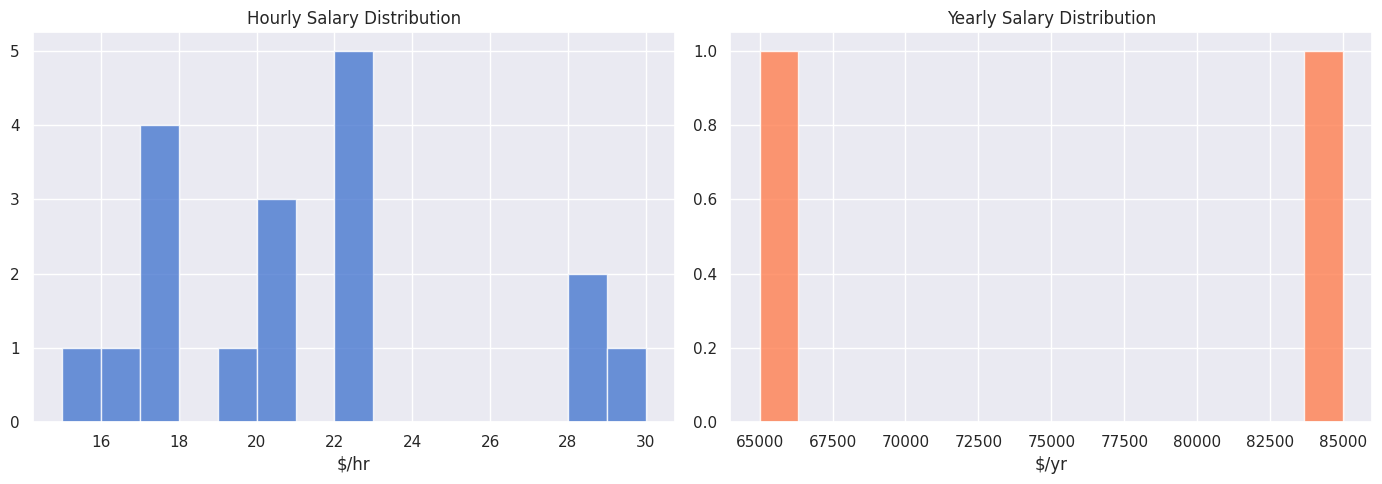

,salary_min,salary_max,salary_period,title,company
0,17.0,22.0,hourly,Barista - Store 12345,Starbucks
1,20.0,28.0,hourly,Shift Supervisor - Store 67890,Starbucks
2,17.0,22.0,hourly,Barista - Store 12345,Starbucks
3,17.5,22.0,hourly,Barista - Store #6281 (Capitol Hill),Starbucks
4,20.0,28.0,hourly,Shift Supervisor - Store #10421,Starbucks
5,65000.0,85000.0,yearly,Store Manager - Store #5512 (Downtown),Starbucks
6,17.5,22.0,hourly,Barista - Store #6281 (Capitol Hill),Starbucks
7,15.0,19.0,hourly,Broista (Barista),Dutch Bros Coffee
8,16.0,20.0,hourly,barista - Store 9983,Starbucks
9,22.0,30.0,hourly,Shift Manager,Starbucks


In [6]:
df_salary = pd.read_sql_query("""
    SELECT
        o.salary_min,
        o.salary_max,
        o.salary_period,
        j.title,
        c.name AS company
    FROM observations o
    JOIN jobs j ON o.job_id = j.id
    JOIN companies c ON j.company_id = c.id
    WHERE o.salary_min IS NOT NULL OR o.salary_max IS NOT NULL
""", conn)

if len(df_salary) > 0:
    hourly = df_salary[df_salary["salary_period"] == "hourly"]
    yearly = df_salary[df_salary["salary_period"] == "yearly"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if len(hourly) > 0:
        axes[0].hist(hourly[["salary_min", "salary_max"]].values.flatten(),
                     bins=15, edgecolor="white", alpha=0.8)
        axes[0].set_title("Hourly Salary Distribution")
        axes[0].set_xlabel("$/hr")

    if len(yearly) > 0:
        axes[1].hist(yearly[["salary_min", "salary_max"]].values.flatten(),
                     bins=15, edgecolor="white", alpha=0.8, color="coral")
        axes[1].set_title("Yearly Salary Distribution")
        axes[1].set_xlabel("$/yr")

    plt.tight_layout()
    plt.show()
else:
    print("No salary data available yet.")

df_salary

## 6. Top Locations

In [ ]:
df_locations = pd.read_sql_query("""
    SELECT l.city, l.state, l.country, l.is_remote,
           COUNT(o.id) AS observation_count
    FROM locations l
    JOIN observations o ON o.location_id = l.id
    GROUP BY l.id
    ORDER BY observation_count DESC
    LIMIT 15
""", conn)

df_locations["label"] = df_locations.apply(
    lambda r: f"{r['city'] or 'Remote'}, {r['state'] or ''}", axis=1
)

fig, ax = plt.subplots()
ax.barh(df_locations["label"], df_locations["observation_count"],
        color=sns.color_palette("coolwarm", len(df_locations)))
ax.set_xlabel("Observations")
ax.set_title("Top Locations by Observation Volume")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

df_locations[["city", "state", "country", "is_remote", "observation_count"]]

## 7. Job Freshness (First Seen vs Last Seen)

In [ ]:
df_freshness = pd.read_sql_query("""
    SELECT
        j.title,
        c.name AS company,
        j.source,
        j.first_seen,
        j.last_seen,
        COUNT(o.id) AS observation_count,
        ROUND(JULIANDAY(j.last_seen) - JULIANDAY(j.first_seen), 2) AS days_active
    FROM jobs j
    JOIN companies c ON j.company_id = c.id
    LEFT JOIN observations o ON o.job_id = j.id
    GROUP BY j.id
    ORDER BY days_active DESC
    LIMIT 25
""", conn)

df_freshness["first_seen"] = pd.to_datetime(df_freshness["first_seen"])
df_freshness["last_seen"] = pd.to_datetime(df_freshness["last_seen"])

df_freshness[["title", "company", "source", "first_seen", "last_seen",
              "days_active", "observation_count"]]

## 8. Full Jobs Table

In [9]:
df_all_jobs = pd.read_sql_query("""
    SELECT
        j.id,
        j.title,
        c.name AS company,
        j.source,
        j.source_job_id,
        j.url,
        j.first_seen,
        j.last_seen
    FROM jobs j
    JOIN companies c ON j.company_id = c.id
    ORDER BY j.last_seen DESC
""", conn)

df_all_jobs

,id,title,company,source,source_job_id,url,first_seen,last_seen
0,44,BARISTA (FULL TIME),Eurest USA,linkedin.com,4345503540,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.767877,2026-03-16 06:53:44.874017
1,56,Barista - Anderson Lane,Summer Moon Coffee,linkedin.com,4359109449,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.788776,2026-03-16 06:53:44.872807
2,55,Starbucks Barista (T1066),Target,linkedin.com,4372215112,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.787381,2026-03-16 06:53:44.871609
3,54,Starbucks Barista (T2495),Target,linkedin.com,4373520712,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.785934,2026-03-16 06:53:44.870411
4,53,Barista - San Marcus,Summer Moon Coffee,linkedin.com,4359172549,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.784369,2026-03-16 06:53:44.869210
5,52,Barista - BSWH Lakeway,Aramark,linkedin.com,4375134277,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.782799,2026-03-16 06:53:44.868008
6,51,Barista - Kyle,Summer Moon Coffee,linkedin.com,4359147504,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.779528,2026-03-16 06:53:44.865406
7,50,Barista - Round Rock,Summer Moon Coffee,linkedin.com,4359138840,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.777936,2026-03-16 06:53:44.864196
8,49,Barista - West Lake,Summer Moon Coffee,linkedin.com,4359138915,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.776497,2026-03-16 06:53:44.862987
9,48,Barista - Circle C,Summer Moon Coffee,linkedin.com,4359079730,https://www.linkedin.com/jobs/search-results/?...,2026-03-16 06:53:44.774957,2026-03-16 06:53:44.861788


In [ ]:
conn.close()
print("Database connection closed.")